### Линейные слои модели `unsloth/Llama-3.2-1B-Instruct`

| layer     |   IN |    OUT | copies |
|-----------|-----:|-------:|-------:|
| q_proj    | 2048 |   2048 |     16 |
| k_proj    | 2048 |    512 |     16 |
| v_proj    | 2048 |    512 |     16 |
| o_proj    | 2048 |   2048 |     16 |
| gate_proj | 2048 |   8192 |     16 |
| up_proj   | 2048 |   8192 |     16 |
| down_proj | 8192 |   2048 |     16 |
| lm_head   | 2048 | 128256 |      1 |

##### batch_size для тестирования: 128, 512, 2048


In [ ]:
import torch
import triton
import triton.language as tl
import time
from tabulate import tabulate

from triton_kernels.quantize_kernel import quantize_rowwise_int4, dequantize_rowwise_int4
from triton_kernels.matmul_int4 import matmul_x16_w4_ref, matmul_x16_w4, matmul_x16_w4_autotuned


def torch_matmul_x16_w4(x, w_packed, w_scales, in_features):
    return matmul_x16_w4_ref(x, w_packed, w_scales, in_features)


def get_time(k, fn, repeat=100):
    for _ in range(repeat // 2):
        fn()

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(repeat):
        fn()
    torch.cuda.synchronize()
    end = time.time()
    ms = (end - start) / repeat * 1000
    return f"{ms:.3f} ms"


dimensions = [
    # q_proj
    (128,  2048, 2048),
    (512,  2048, 2048),
    (2048, 2048, 2048),
    "none",
    # k_proj
    (128,  2048, 512),
    (512,  2048, 512),
    (2048, 2048, 512),
    "none",
    # v_proj
    (128,  2048, 512),
    (512,  2048, 512),
    (2048, 2048, 512),
    "none",
    # o_proj
    (128,  2048, 2048),
    (512,  2048, 2048),
    (2048, 2048, 2048),
    "none",
    # gate_proj
    (128,  2048, 8192),
    (512,  2048, 8192),
    (2048, 2048, 8192),
    "none",
    # up_proj
    (128,  2048, 8192),
    (512,  2048, 8192),
    (2048, 2048, 8192),
    "none",
    # down_proj
    (128,  8192, 2048),
    (512,  8192, 2048),
    (2048, 8192, 2048),
    "none",
    # lm_head
    (128,  2048, 128256),
    (512,  2048, 128256),
    (2048, 2048, 128256),
]

BLOCK_M = 32
BLOCK_N = 32
BLOCK_K = 32

results = []

for dim in dimensions:
    if dim != "none":
        B, IN, OUT = dim
        x = torch.randn(B, IN, device="cuda", dtype=torch.float16)
        w = torch.randn(OUT, IN, device="cuda", dtype=torch.float16)
        w_packed, w_scales = quantize_rowwise_int4(w)

        triton_time = get_time("Triton", lambda: matmul_x16_w4(x, w_packed, w_scales, IN, BLOCK_M, BLOCK_N, BLOCK_K))
        triton_time_autotuned = get_time("Triton Autotuned", lambda: matmul_x16_w4_autotuned(x, w_packed, w_scales, IN))
        pytorch_time = get_time("PyTorch", lambda: torch_matmul_x16_w4(x, w_packed, w_scales, IN))

        results.append([
            dim,
            triton_time,
            triton_time_autotuned,
            pytorch_time
        ])
    else:
        results.append([
            '',
            '',
            '',
            ''
        ])


headers = ["Dimensions (B, IN, OUT)", "Triton Time", "Triton Autotuned Time", "PyTorch Time"]
print(tabulate(results, headers=headers, tablefmt="grid"))


+---------------------------+---------------+-------------------------+----------------+
| Dimensions (B, IN, OUT)   | Triton Time   | Triton Autotuned Time   | PyTorch Time   |
+===========================+===============+=========================+================+
| (128, 2048, 2048)         | 0.040 ms      | 0.047 ms                | 0.185 ms       |
+---------------------------+---------------+-------------------------+----------------+
| (512, 2048, 2048)         | 0.108 ms      | 0.063 ms                | 0.208 ms       |
+---------------------------+---------------+-------------------------+----------------+
| (2048, 2048, 2048)        | 0.393 ms      | 0.153 ms                | 0.236 ms       |
+---------------------------+---------------+-------------------------+----------------+
|                           |               |                         |                |
+---------------------------+---------------+-------------------------+----------------+
| (128, 2048, 512)   

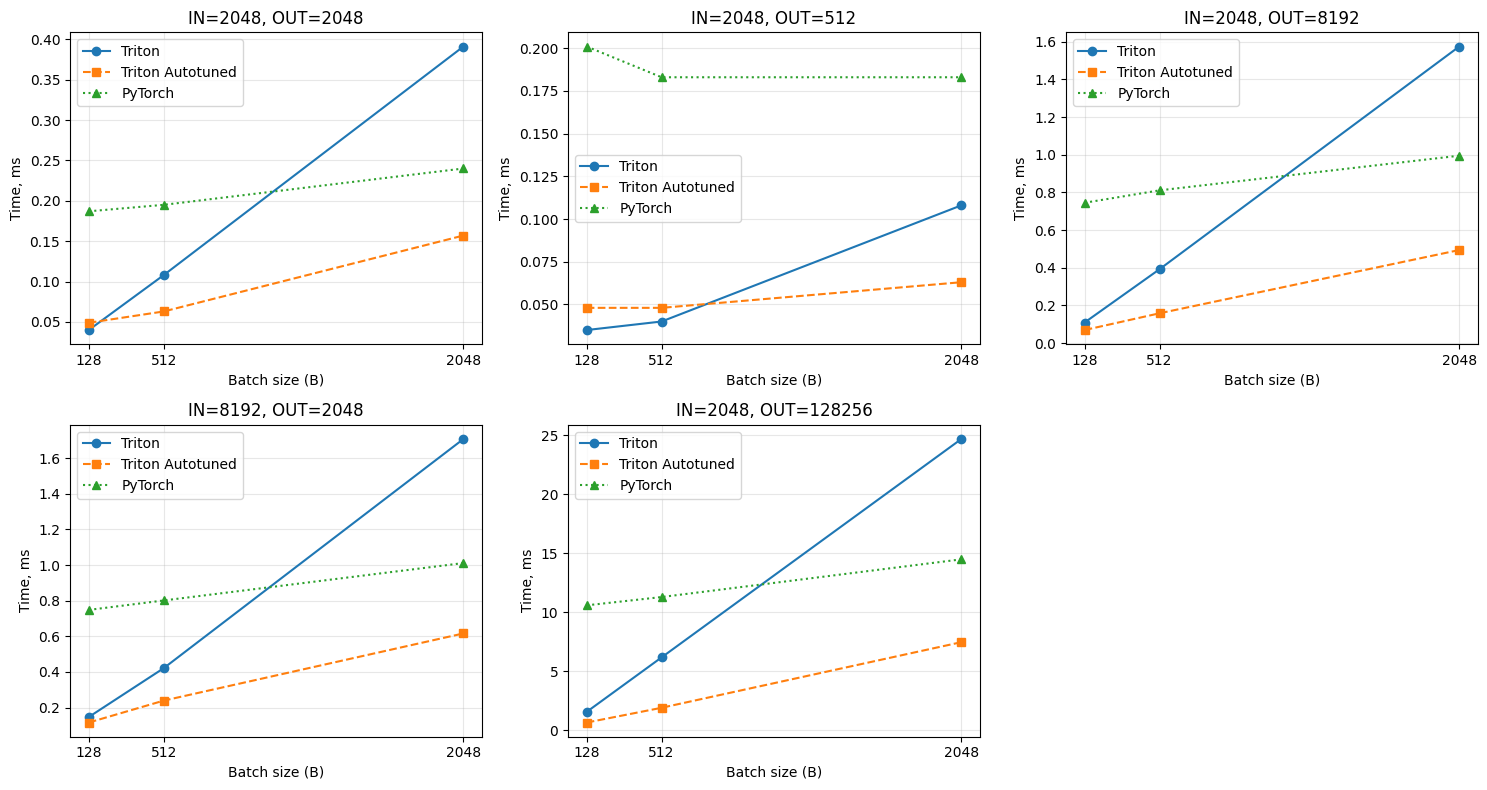

In [6]:
import math
import matplotlib.pyplot as plt
from collections import defaultdict


def _parse_ms(s):
    return float(s.replace(" ms", "")) if s else None


# Группируем по (IN, OUT); для повторяющихся (B, IN, OUT) берём первое измерение
by_shape = defaultdict(lambda: {"batch": [], "triton": [], "autotuned": [], "pytorch": []})
seen = set()
for row in results:
    dim = row[0]
    if dim == "":
        continue
    B, IN, OUT = dim
    if (B, IN, OUT) in seen:
        continue
    seen.add((B, IN, OUT))
    d = by_shape[(IN, OUT)]
    d["batch"].append(B)
    d["triton"].append(_parse_ms(row[1]))
    d["autotuned"].append(_parse_ms(row[2]))
    d["pytorch"].append(_parse_ms(row[3]))


methods = [
    ("triton",    "o", "-",  "Triton"),
    ("autotuned", "s", "--", "Triton Autotuned"),
    ("pytorch",   "^", ":",  "PyTorch"),
]

n_shapes = len(by_shape)
ncols = 3
nrows = math.ceil(n_shapes / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for idx, ((IN, OUT), d) in enumerate(by_shape.items()):
    ax = axes[idx // ncols][idx % ncols]
    order = sorted(range(len(d["batch"])), key=lambda k: d["batch"][k])
    batch_sorted = [d["batch"][k] for k in order]
    for method_key, marker, linestyle, method_label in methods:
        y = [d[method_key][k] for k in order]
        ax.plot(batch_sorted, y, marker=marker, linestyle=linestyle, label=method_label)
    ax.set_xlabel("Batch size (B)")
    ax.set_ylabel("Time, ms")
    ax.set_title(f"IN={IN}, OUT={OUT}")
    ax.set_xticks(batch_sorted)
    ax.grid(True, alpha=0.3)
    ax.legend()

for idx in range(n_shapes, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis("off")

plt.tight_layout()
plt.show()
